In [3]:
import pandas as pd
import numpy as np

In [5]:
%pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [6]:
retail = pd.read_excel("Online Retail.xlsx")
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
print("Dataset shape:", retail.shape)
print("\nColumn names:")
print(retail.columns.tolist())

Dataset shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [8]:
retail.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [9]:
print("Missing values by column:")
print(retail.isnull().sum())

print("\nDuplicate rows:", retail.duplicated().sum())

Missing values by column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows: 5268


In [10]:
print("Cancelled invoices:",
      retail["InvoiceNo"].astype(str).str.startswith("C").sum())

print("Quantity <= 0:",
      (retail["Quantity"] <= 0).sum())

print("UnitPrice <= 0:",
      (retail["UnitPrice"] <= 0).sum())

Cancelled invoices: 9288
Quantity <= 0: 10624
UnitPrice <= 0: 2517


In [11]:
retail_clean = retail.copy()

retail_clean = retail_clean.dropna(subset=["CustomerID"])
retail_clean = retail_clean.drop_duplicates()

retail_clean = retail_clean[
    ~retail_clean["InvoiceNo"].astype(str).str.startswith("C")
]

retail_clean = retail_clean[
    (retail_clean["Quantity"] > 0) &
    (retail_clean["UnitPrice"] > 0)
]

retail_clean["CustomerID"] = retail_clean["CustomerID"].astype(int)

retail_clean["TotalPrice"] = (
    retail_clean["Quantity"] * retail_clean["UnitPrice"]
)

print("Cleaned dataset shape:", retail_clean.shape)
print("Missing CustomerID:", retail_clean["CustomerID"].isnull().sum())
print("Duplicates:", retail_clean.duplicated().sum())

Cleaned dataset shape: (392692, 9)
Missing CustomerID: 0
Duplicates: 0


In [12]:
# Choose a reference date one day after the latest transaction
snapshot_date = retail_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = retail_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

print(rfm.head())
print("\nRFM shape:", rfm.shape)

   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40

RFM shape: (4338, 4)


In [13]:
print(rfm[["Recency", "Frequency", "Monetary"]].describe())

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


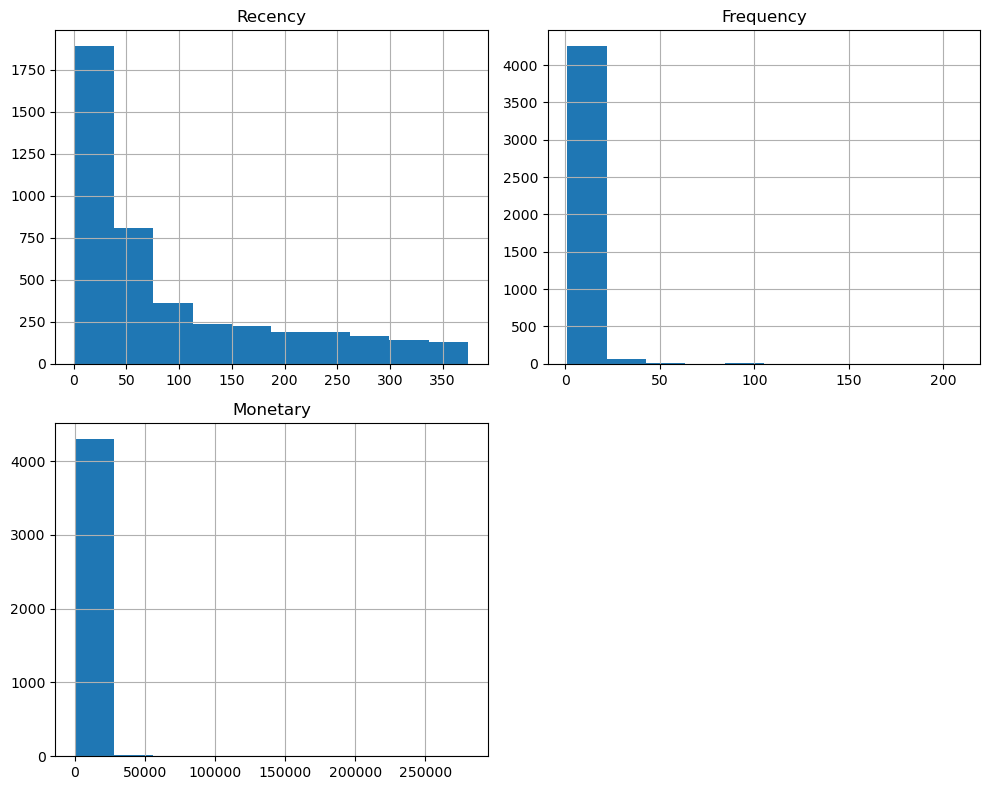

In [14]:
import matplotlib.pyplot as plt

rfm[["Recency", "Frequency", "Monetary"]].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [15]:
rfm_transformed = rfm.copy()

rfm_transformed["Recency"] = np.log1p(rfm_transformed["Recency"])
rfm_transformed["Frequency"] = np.log1p(rfm_transformed["Frequency"])
rfm_transformed["Monetary"] = np.log1p(rfm_transformed["Monetary"])

print(rfm_transformed[["Recency", "Frequency", "Monetary"]].describe())

           Recency    Frequency     Monetary
count  4338.000000  4338.000000  4338.000000
mean      3.830734     1.345582     6.588562
std       1.340261     0.683104     1.258438
min       0.693147     0.693147     1.558145
25%       2.944439     0.693147     5.728418
50%       3.951244     1.098612     6.506636
75%       4.962845     1.791759     7.415535
max       5.926926     5.347108    12.543284


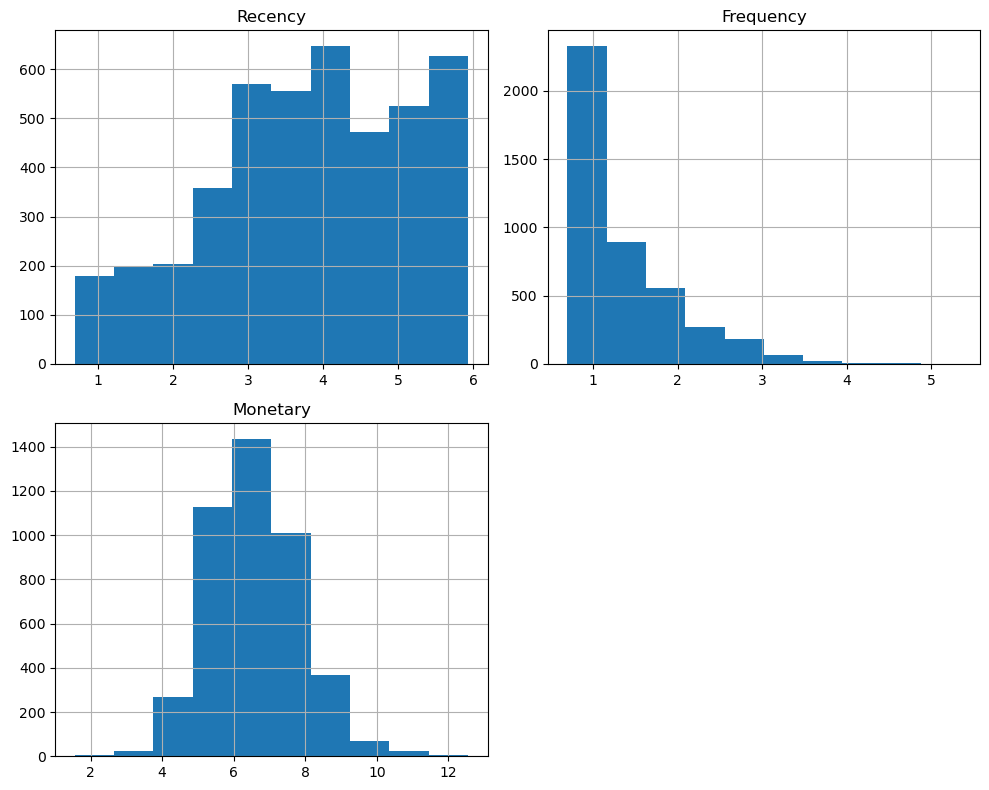

In [16]:
rfm_transformed[["Recency", "Frequency", "Monetary"]].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_transformed[["Recency", "Frequency", "Monetary"]]
)

print("Scaled RFM shape:", rfm_scaled.shape)
print("Mean after scaling:", rfm_scaled.mean(axis=0))
print("Standard deviation after scaling:", rfm_scaled.std(axis=0))

Scaled RFM shape: (4338, 3)
Mean after scaling: [-8.02595529e-17 -8.18975030e-18 -3.66900813e-16]
Standard deviation after scaling: [1. 1. 1.]


In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores[k] = score

    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.4328
k = 3, Silhouette Score = 0.3365
k = 4, Silhouette Score = 0.3375
k = 5, Silhouette Score = 0.3162
k = 6, Silhouette Score = 0.3124
k = 7, Silhouette Score = 0.3092
k = 8, Silhouette Score = 0.3033


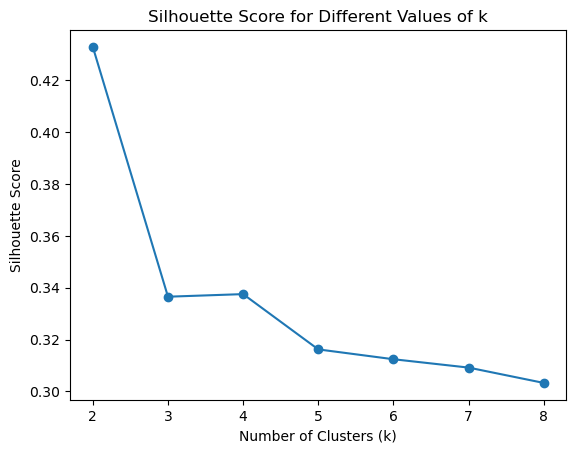

In [19]:
plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Values of k")
plt.show()

In [20]:
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans_final.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby("Cluster").agg({
    "CustomerID": "count",
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).rename(columns={"CustomerID": "Customers"})

print(cluster_summary)

         Customers     Recency  Frequency     Monetary
Cluster                                               
0             2672  134.091317   1.671033   495.594945
1             1666   25.888956   8.443577  4539.603362


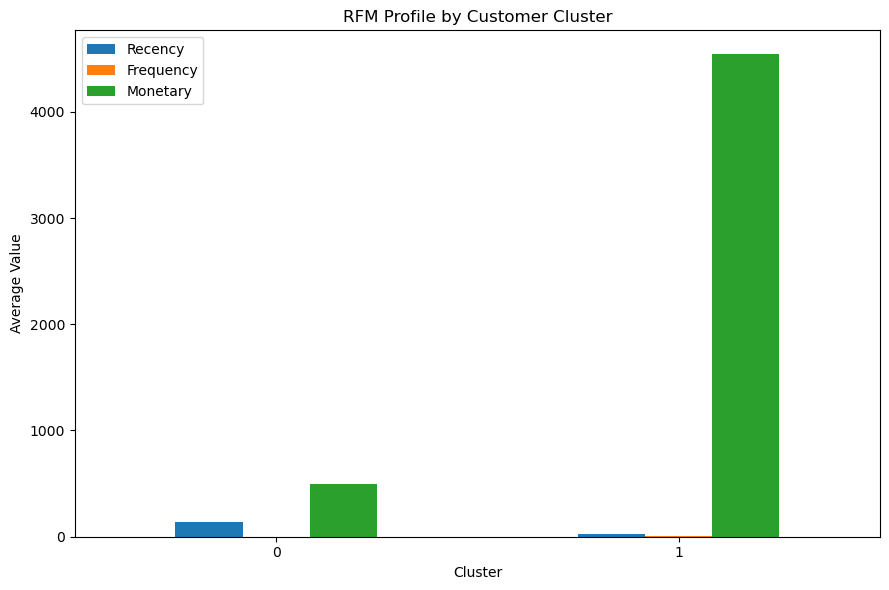

In [21]:
cluster_summary[["Recency", "Frequency", "Monetary"]].plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("RFM Profile by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

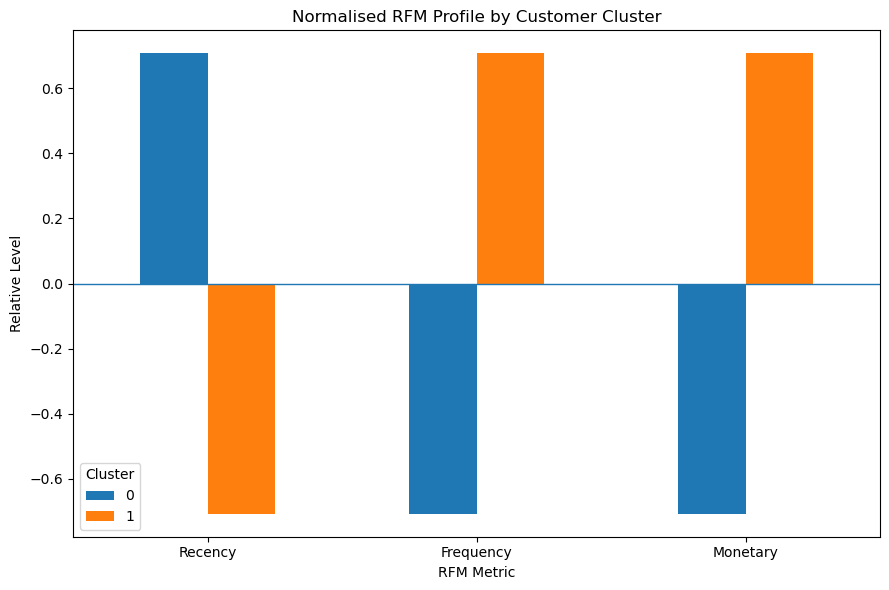

In [24]:
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

cluster_profile_normalised = (
    cluster_profile - cluster_profile.mean()
) / cluster_profile.std()

cluster_profile_normalised.T.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Normalised RFM Profile by Customer Cluster")
plt.xlabel("RFM Metric")
plt.ylabel("Relative Level")
plt.xticks(rotation=0)
plt.axhline(0, linewidth=1)
plt.tight_layout()

plt.savefig(
    "rfm_cluster_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation of K-means Customer Segmentation

K-means clustering was applied to the transformed and standardised RFM features. The silhouette score was highest for two clusters (approximately 0.433), so k = 2 was selected.

Cluster 0 contains customers with higher recency and lower frequency and monetary values, indicating a less active and lower-value customer group. Cluster 1 contains customers with lower recency and substantially higher frequency and spending, representing a more active and higher-value group.

These segments could support different customer strategies. For example, Cluster 1 may be suitable for loyalty and retention initiatives, while Cluster 0 may be targeted with re-engagement campaigns.